In [1]:
import os
import numpy as np

import darklim

from darklim.sensitivity._random_sampling import pdf_sampling

from scipy.special import factorial
import scipy.stats as stats

import matplotlib.pyplot as plt
if None != os.getenv('NERSC_HOST'):
    import matplotlib.font_manager as font_manager
    font_manager.fontManager.addfont('/global/cfs/cdirs/lz/physics/WS/SR1/msttcorefonts/Times_New_Roman.ttf')

import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
from multihist import Hist1d

%matplotlib inline

In [39]:
def pdf_integral(pdf,e_low,e_high,npts):
    '''
    assumes 'pdf' is a lambda function
    '''
    en_interp = np.geomspace(e_low,e_high, num=npts)
    return np.trapz( pdf(en_interp), x=en_interp)

def power_bkgd(x,amplitude,abs_power):
    return amplitude * x**(-1*abs_power)

def power(x,amplitude,abs_power):
    return amplitude * x**(-1*abs_power)

def shifted_power(x,a,b):
    '''
    normalized
    '''
    return (x+a)**(-b) * (b-1) * a**(b-1)

def shifted_power_cdf(x,a,b):
    '''
    normalized
    '''
    return 1-( (x+a)/a )**(1-b)

def expo(x, a):
    '''
    normalized
    '''
    return a * np.exp(-x * a)

def expo_cdf(x,a):
    return 1 - np.exp(-x * a)

def expo_bkg(x, a, R):
    '''
    *not normalized* has rate number in front
    '''
    return R * np.exp(-x * a)

In [18]:
# LEE parameter values for various scenarios
lee_pars = {}

lee_pars['57_shared_expo1'] = np.array([1/1.0545e-4,2.474e17])
lee_pars['57_shared_expo2'] = np.array([1/2.5326e-3,7.329e9])
lee_pars['57_singles_expo1'] = np.array([1/1.2545e-4,6.732e14])

In [19]:
# Constants

n_devices = 1
sigma0 = 1e-37 # cm2
he_gain = 0.15
tm = 'He'
m_dms = np.array([0.1,0.5,1])

energy_res = 0.200e-3 # energy resolution in keV
threshold = 5*energy_res



In [20]:
lee_pars['57_shared_expo1']

array([9.48316738e+03, 2.47400000e+17])

In [40]:
# 

power_pdf = lambda x: power_bkgd(x,1.4e-8, 5.77)+power_bkgd(x,0.107, 2.72)

# run 57 expo LEE
expo_pdf = lambda x: expo_bkg(x, *lee_pars['57_shared_expo1']) \
                    + expo_bkg(x, *lee_pars['57_shared_expo2']) \
                    + expo_bkg(x, *lee_pars['57_singles_expo1'])

e_low, e_high = 5e-4, 1.0
en_interp = np.geomspace(e_low,e_high, num=10000)

power_rate = pdf_integral(power_pdf,threshold,e_high,10000)
expo_rate = pdf_integral(expo_pdf,threshold,e_high,10000)

# WIMP shapes:
drdefunction = [ lambda x,m: darklim.sensitivity.drde_wimp_obs( x, m, sigma0, tm, he_gain ) for m in m_dms ]

wimpe_low, wimpe_high = 1e-4, 1.0
wimp_en_interp = np.geomspace(wimpe_low,wimpe_high, num=10000)

print(expo_rate)

2027578262.4562855


done.


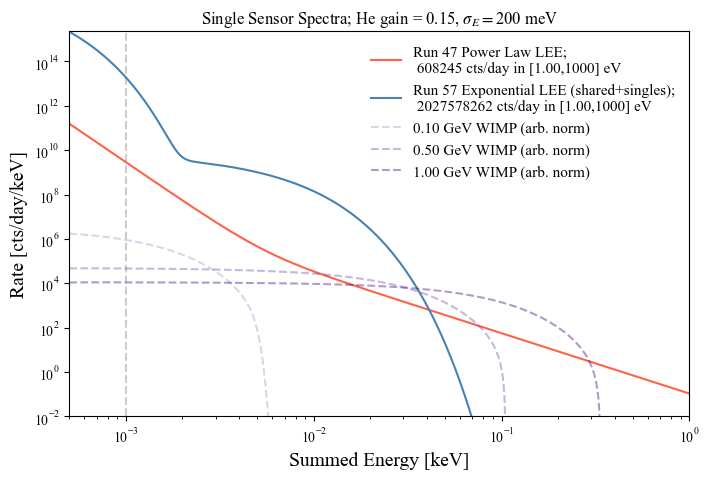

In [41]:
### 

plot_wimp=True

fig, ax = plt.subplots(1,figsize=(8,5))

n_lines = len(m_dms)
#cmaps = ['Blues','Oranges','Greens']
cmap = matplotlib.colormaps['Purples']
wimpcolors = cmap(np.linspace(0.5, 1, n_lines))

###################################################################

plt.plot(en_interp,power_pdf(en_interp),lw=1.5,color='tomato',
         label='Run 47 Power Law LEE;\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(power_rate,threshold*1e3,e_high*1e3))

plt.plot(en_interp,expo_pdf(en_interp),lw=1.5,color='steelblue',
         label='Run 57 Exponential LEE (shared+singles);\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(expo_rate,threshold*1e3,e_high*1e3))

# plot WIMP shapes for comparison - note these have He gain and energy resolution for a single device applied
if plot_wimp:
    for ii, mass in enumerate(m_dms):
        init_rate = drdefunction[ii](wimp_en_interp,mass)    
        smeared_rate = darklim.limit.gauss_smear(wimp_en_interp, init_rate, np.sqrt(n_devices)*energy_res)
        plt.plot(wimp_en_interp,smeared_rate,
                 ls='--', color=wimpcolors[ii],alpha=0.4,
                 label='{:.2f} GeV WIMP (arb. norm)'.format(mass))

ax.axvline(threshold,ls='--',color='grey',alpha=0.4)

ax.set_xlim(e_low,e_high)
ax.set_xscale('log')
ax.set_ylim(1e-2,None)
ax.set_yscale('log')
#ax.legend(loc='upper right', title='{:d} Total Devices\nCoincidence Level:'.format(m), frameon=False,ncol=1,fontsize=13,title_fontsize=15)
#ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.legend(loc='upper right', frameon=False,ncol=1,fontsize=11)
ax.set_xlabel('Summed Energy [keV]',fontsize=14)
ax.set_ylabel('Rate [cts/day/keV]',fontsize=14)
ax.set_title(r'Single Sensor Spectra; He gain = {:0.2f}, $\sigma_E=${:0.0f} meV'.format(he_gain,energy_res*1e6))
print('done.')


done.


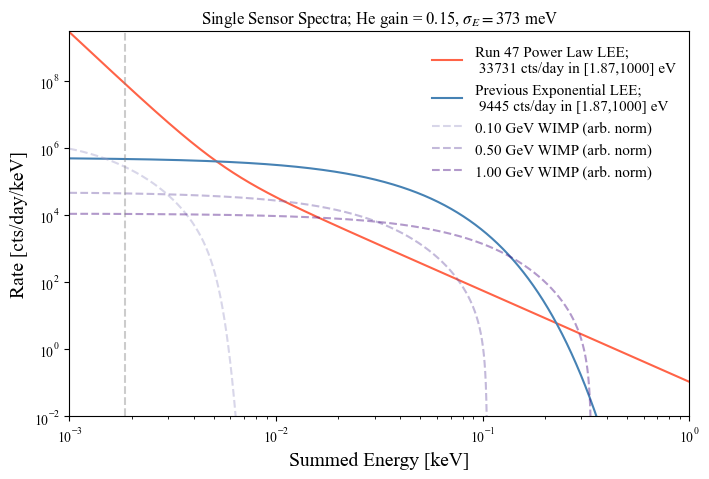

In [9]:
### don't delete... older vesrion of plot

# two LEEs:
power_pdf = lambda x: power_bkgd(x,1.4e-8, 5.77)+power_bkgd(x,0.107, 2.72)
expo_pdf = lambda x: darklim.sensitivity.n_fold_lee(x,m=1,n=1,e0=0.020,R=0.12,w=100e-6)

e_low, e_high = 1e-3, 1.0
en_interp = np.geomspace(e_low,e_high, num=10000)

power_rate = pdf_integral(power_pdf,threshold,e_high,10000)
expo_rate = pdf_integral(expo_pdf,threshold,e_high,10000)

# WIMP shapes:
drdefunction = [ lambda x,m: darklim.sensitivity.drde_wimp_obs( x, m, sigma0, tm, he_gain ) for m in m_dms ]

wimpe_low, wimpe_high = 1e-4, 1.0
wimp_en_interp = np.geomspace(wimpe_low,wimpe_high, num=10000)

#####
fig, ax = plt.subplots(1,figsize=(8,5))


n_lines = len(m_dms)
#cmaps = ['Blues','Oranges','Greens']
cmap = matplotlib.colormaps['Purples']
wimpcolors = cmap(np.linspace(0.5, 1, n_lines))



###################################################################

plt.plot(en_interp,power_pdf(en_interp),lw=1.5,color='tomato',
         label='Run 47 Power Law LEE;\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(power_rate,threshold*1e3,e_high*1e3))

plt.plot(en_interp,expo_pdf(en_interp),lw=1.5,color='steelblue',
         label='Previous Exponential LEE;\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(expo_rate,threshold*1e3,e_high*1e3))

# plot WIMP shapes for comparison - note these have He gain and energy resolution for a single device applied
for ii, mass in enumerate(m_dms):
    init_rate = drdefunction[ii](wimp_en_interp,mass)    
    smeared_rate = darklim.limit.gauss_smear(wimp_en_interp, init_rate, np.sqrt(n_devices)*energy_res)
    #plt.plot(en_interp,init_rate)
    plt.plot(wimp_en_interp,smeared_rate,
             ls='--', color=wimpcolors[ii],alpha=0.4,
             label='{:.2f} GeV WIMP (arb. norm)'.format(mass))

ax.axvline(threshold,ls='--',color='grey',alpha=0.4)

ax.set_xlim(e_low,e_high)
ax.set_xscale('log')
ax.set_ylim(1e-2,None)
ax.set_yscale('log')
#ax.legend(loc='upper right', title='{:d} Total Devices\nCoincidence Level:'.format(m), frameon=False,ncol=1,fontsize=13,title_fontsize=15)
#ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.legend(loc='upper right', frameon=False,ncol=1,fontsize=11)
ax.set_xlabel('Summed Energy [keV]',fontsize=14)
ax.set_ylabel('Rate [cts/day/keV]',fontsize=14)
ax.set_title(r'Single Sensor Spectra; He gain = 0.15, $\sigma_E=373$ meV')
print('done.')


m =  0.1
5539.229100502662
m =  0.5
7080.513398517891
m =  1.0
5391.908251843492


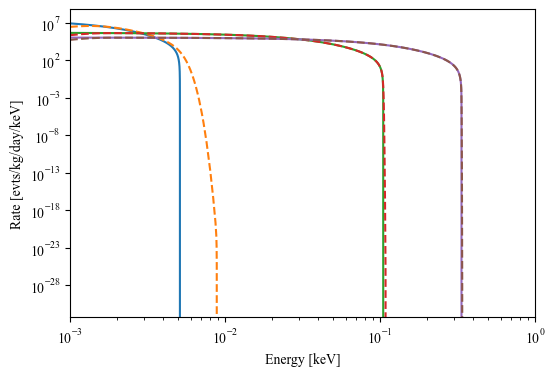

In [22]:
# test making the drdefunction as in run_sim:
n_devices = 1
sigma0 = 1e-36 # cm2
he_gain = 0.15
tm = 'He'
m_dms = np.array([0.1,0.5,1])

drdefunction = [ lambda x,m: darklim.sensitivity.drde_wimp_obs( x, m, sigma0, tm, he_gain ) for m in m_dms ]
elow = threshold
ehigh = 10
en_interp = np.geomspace(e_low, e_high, int(1e5))

fig, ax = plt.subplots(1,figsize=(6,4))
for ii, mass in enumerate(m_dms):
    print('m = ',mass)
    
    #obs_dm_func = lambda x: darklim.sensitivity.drde_wimp_obs( x, mass, sigma0, tm, he_gain )
    #init_rate = obs_dm_func(en_interp)
    
    init_rate = drdefunction[ii](en_interp,mass)
    
    smeared_rate = darklim.limit.gauss_smear(en_interp, init_rate, np.sqrt(n_devices)*energy_res)
    
    plt.plot(en_interp,init_rate)
    plt.plot(en_interp,smeared_rate,ls='--')
    
    print(np.trapz(init_rate,x=en_interp))

ax.set_ylabel('Rate [evts/kg/day/keV]')
ax.set_xlabel('Energy [keV]')
ax.set_xlim(e_low,e_high)
ax.set_xscale('log')
ax.set_yscale('log')

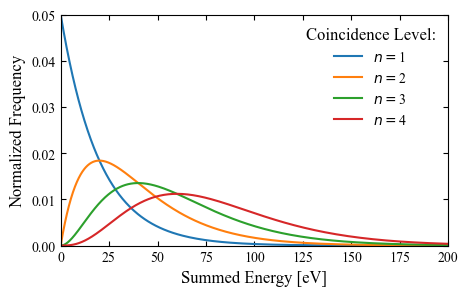

In [18]:
fig, ax = plt.subplots(1,figsize=(5,3))

lam = 1/20
ks = np.arange(1,5)
x = np.geomspace(1e-3,1e3,1000)

for k in ks:

    dist = stats.erlang.pdf(x,a=k,loc=0,scale=1/lam)
    dist2 = stats.expon.pdf(x,loc=0,scale=1/lam)

    plt.plot(x, dist,label=r'$n=$'+'{:d}'.format(k))
    
#plt.plot(x, dist2,'r--',label='Expo. Dist')
ax.set_xlim(0,200)
ax.set_ylim(0,0.05)
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend(loc='upper right',frameon=False,title='Coincidence Level:',title_fontsize=12)
ax.set_xlabel('Summed Energy [eV]',fontsize=12)
ax.set_ylabel('Normalized Frequency',fontsize=12)

plt.savefig('./pretty_plots/erlang.png',facecolor='white',bbox_inches='tight')

In [3]:
# generate ntoys
e_low = 1e-6
e_high = 10
npts = 1000

ntoys = 1000000

lam = 1/0.020
pdf = lambda x: stats.expon.pdf(x,loc=0,scale=1/lam)

energy_res = 0.373e-3 # energy resolution in keV
sigma = 50
threshold = sigma*energy_res
print('threshold = {:0.3e} keV'.format(threshold))

#evts_sim = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )

threshold = 1.865e-02 keV


In [34]:
# generate toys from m devices with n-fold coincidence

sum_all_energy = False


devices = np.array([2,3,4])

summed_energy = {}

for i,m in enumerate(devices):
    
    # simulate events in all devices:
    evts = np.zeros((m,ntoys))
    for d in range(m):
        evts[d,:] = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )
    
    #print( evts[0,:10] )
    evts[np.where(evts<threshold)] = 0 # sets events below threshold to zero
    #print( evts[0,:10] )
    summed_energy[m] = np.sum(evts,axis=0) # sum energy accross devices
    
    #coinc = np.arange(2,m+1)
    #print('{} devices. coinc levels considered are '.format(m),coinc)
    
    #for j,n in enumerate(coinc):
    #    print('coinc level is ',n)
    #    
    #    # apply threshold to the first n channels
    #    for d in range(n):
    #        evts[d,:]
print('done.')

done.


Text(0.5, 0, 'Summed Energy [keV]')

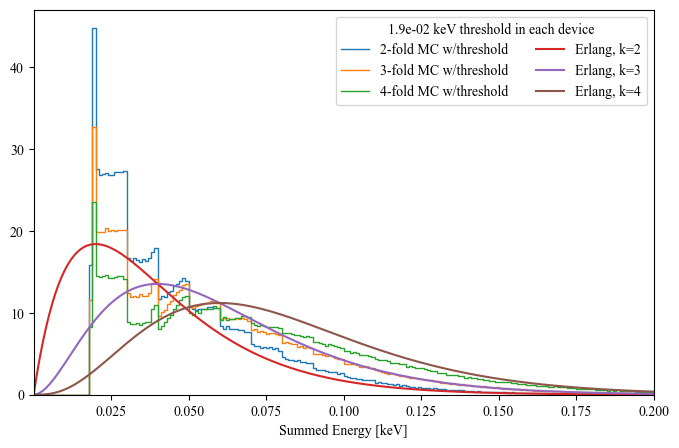

In [35]:
# histogram the simulated toys
fig, ax = plt.subplots(1,figsize=(8,5))

for i,m in enumerate(devices):
    h = Hist1d(summed_energy[m],bins=10000,range=(e_low,e_high))
    bw = h.bin_centers[1]-h.bin_centers[0]
    h.plot(scale_histogram_by=1/bw,lw=1,label='{}-fold MC w/threshold'.format(m),normed=True)

#x = np.geomspace(e_low,e_high,10000)
x = np.linspace(e_low,e_high,10000)
for k in devices:
    dist = stats.erlang.pdf(x,a=k,loc=0,scale=1/lam)
    plt.plot(x, dist/np.trapz(dist, x=x),label='Erlang, k={:d}'.format(k))
        

ax.set_xlim(e_low,0.2)
#ax.set_xscale('log')
ax.set_ylim(0,None)
ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.set_xlabel('Summed Energy [keV]')

In [25]:
test = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )
print(test)
test[np.where(test<0.02)] = 0
print(test)

[0.01814909 0.08861029 0.02425482 ... 0.00364906 0.00120441 0.01921873]
[0.         0.08861029 0.02425482 ... 0.         0.         0.        ]


In [24]:
test

array([0.06928629, 0.        , 0.        , ..., 0.        , 0.        ,
       0.        ])

10000


Text(0.5, 0, 'Summed Energy [keV]')

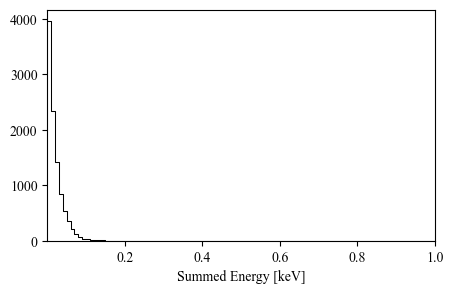

In [6]:
# histogram the simulated toys
fig, ax = plt.subplots(1,figsize=(5,3))

h = Hist1d(evts_sim,bins=npts,range=(e_low,e_high))
h.plot(color='black',lw=0.75)

print(h.n)

ax.set_xlim(e_low,1)
#ax.set_xscale('log')
ax.set_ylim(0,None)
#ax.legend(loc='upper right')
ax.set_xlabel('Summed Energy [keV]')

In [4]:
# Detector info setup

#n_devices = 4
#coinc = 2
#window = 100e-6 # s

mass_det = 0.00115 # mass in kg
time_elapsed = 1000 # days
efficiency = 1.0

tm = 'He' # target name

energy_res = 0.373e-3 # energy resolution in keV
#threshold = coinc*5*energy_res

print('detector mass is {} kg = {} g'.format(mass_det,mass_det*1000))
print('run time is {} days'.format(time_elapsed))
print('exposure is {} kg-days'.format(mass_det*time_elapsed))
#print('threshold = {:0.3f} eV'.format(threshold*1000))
#print('assuming {:d}-fold coincidence amongst {:d} devices in a {:0.1f} microsecond window'.format(coinc,n_devices,window/1e-6))

detector mass is 0.00115 kg = 1.15 g
run time is 1000 days
exposure is 1.15 kg-days


In [ ]:
SE = darklim.sensitivity.SensEst(mass_det, time_elapsed, eff=efficiency, tm=tm)

SE.reset_sim()
#SE.add_flat_bkgd(1) # flat background of 1 DRU
#SE.add_nfold_lee_bkgd(m=4,n=2,w=window)
SE.add_nfold_lee_bkgd(m=n_devices,n=coinc,w=window)

In [ ]:
# p-values to demonstrate the sf and isf functions:
p_sig = np.zeros(6) # p values
sigma = np.zeros(6) # sigmas
for sig in range(1,6):
    p_sig[sig-1] = stats.norm.sf(sig)
    sigma[sig-1] = stats.norm.isf(p_sig[sig-1])
    print('p-value for {:d} sigma is {:0.5e}'.format(sig,p_sig[sig-1]))
    print(' ->check that sigma is {:0.2f}\n'.format(sigma[sig-1]))